# Reading plates

Behind every profile there are images and segmentations. `mantispy.io.read_plate` reads one plate of them
into a {class}`~spatialdata.SpatialData` object: fields of view as Images, the CellProfiler objects as
Labels, the wells as Shapes, and the well- and cell-level measurements as Tables that annotate them.

It reads two layouts, told apart by what sits in the directory you point it at:

- a **Cell Painting Gallery** source, the `images/` and `workspace/` trees of an accession;
- a **CellProfiler export**, the folder the `ExportForSpatialData` module writes out of a pipeline run.

This tutorial uses a synthetic plate, so nothing has to be downloaded first.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import mantispy as mt

sdata = mt.ds.blobs(n_wells=4, n_sites=4)
sdata

SpatialData object
├── Images
│     ├── 'BLOBS01_A01_s1_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A01_s2_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A01_s3_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A01_s4_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A02_s1_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A02_s2_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A02_s3_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A02_s4_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A03_s1_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A03_s2_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A03_s3_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A03_s4_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A04_s1_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A04_s2_image': DataArray[cyx] (5, 64, 64)
│     ├── 'BLOBS01_A04_s3_image': DataArray[cyx] (5, 64, 64)
│     └── 'BLOBS01_A04_s4_image': DataArray[cyx] (5, 64

## Coordinate systems

Every element sits in three coordinate systems: its own field, its well, and the plate. That is what lets the
fields of a well lay out as a mosaic and the wells as a plate map, without anything being resampled.

In [2]:
sorted(sdata.coordinate_systems)[:6]

['BLOBS01',
 'BLOBS01_A01',
 'BLOBS01_A01_s1',
 'BLOBS01_A01_s2',
 'BLOBS01_A01_s3',
 'BLOBS01_A01_s4']

Rendering a well in its own frame puts its four fields where the microscope stage found them:

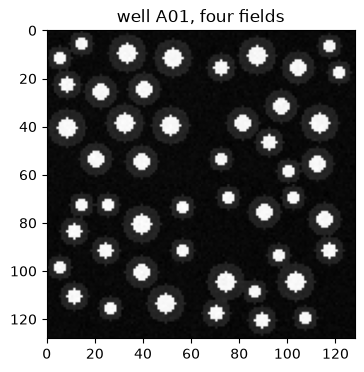

In [3]:
from spatialdata.transformations import get_transformation

fig, ax = plt.subplots(figsize=(4, 4))
for name, image in sdata.images.items():
    if "_A01_" not in name:
        continue
    offset = get_transformation(image, "BLOBS01_A01").to_affine_matrix(input_axes=("y", "x"), output_axes=("y", "x"))
    y, x = offset[0, 2], offset[1, 2]
    ax.imshow(np.asarray(image.sel(c="DNA")), extent=(x, x + 64, y + 64, y), cmap="gray")
ax.set(xlim=(0, 128), ylim=(128, 0), title="well A01, four fields")
plt.show()

## Images and labels

The image of a field carries one channel per stain, named. The labels carry CellProfiler's own object numbers,
so the rows of the cell table join straight onto them.

In [4]:
image = sdata["BLOBS01_A01_s1_image"]
list(image.coords["c"].values)

[np.str_('DNA'),
 np.str_('RNA'),
 np.str_('AGP'),
 np.str_('ER'),
 np.str_('Mito')]

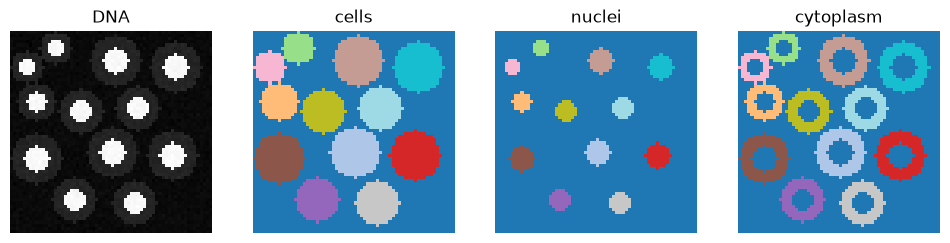

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3))
axes[0].imshow(np.asarray(image.sel(c="DNA")), cmap="gray")
axes[0].set_title("DNA")
for ax, name in zip(axes[1:], ("cells", "nuclei", "cytoplasm"), strict=True):
    ax.imshow(np.asarray(sdata[f"BLOBS01_A01_s1_{name}"]), cmap="tab20")
    ax.set_title(name)
for ax in axes:
    ax.set_axis_off()
plt.show()

Cytoplasm is the cell mask minus the nucleus mask, the way CellProfiler defines it.

## The tables

`cells` holds one row per segmented object and `wells` one row per well. Both are ordinary
{class}`~anndata.AnnData` objects whose `var` is annotated with what each feature name encodes, exactly as
{func}`mantispy.io.read_profiles` annotates a profile it reads from disk.

In [6]:
cells = sdata.tables["cells"]
cells

AnnData object with n_obs × n_vars = 192 × 19
    obs: 'Plate', 'Well', 'Site', 'ObjectNumber', 'region'
    var: 'compartment', 'family', 'channel', 'channel_2', 'n_channels'
    uns: 'spatialdata_attrs'
    layers: None (.X)

In [7]:
cells.var

,compartment,family,channel,channel_2,n_channels
feature,,,,,
Cells_AreaShape_Area,cells,areashape,NaN,NaN,0
Cells_Intensity_MeanIntensity_DNA,cells,intensity,dna,NaN,1
Cells_Intensity_MeanIntensity_RNA,cells,intensity,rna,NaN,1
Cells_Intensity_MeanIntensity_AGP,cells,intensity,agp,NaN,1
Cells_Intensity_MeanIntensity_ER,cells,intensity,er,NaN,1
Cells_Intensity_MeanIntensity_Mito,cells,intensity,mito,NaN,1
Nuclei_AreaShape_Area,nuclei,areashape,NaN,NaN,0
Nuclei_Intensity_MeanIntensity_DNA,nuclei,intensity,dna,NaN,1
Nuclei_Intensity_MeanIntensity_RNA,nuclei,intensity,rna,NaN,1


`region` names the Labels element each row annotates, and `ObjectNumber` the label value inside it:

In [8]:
cells.obs.head()

,Plate,Well,Site,ObjectNumber,region
BLOBS01_A01_s1_cells:1,BLOBS01,A01,1,1,BLOBS01_A01_s1_cells
BLOBS01_A01_s1_cells:2,BLOBS01,A01,1,2,BLOBS01_A01_s1_cells
BLOBS01_A01_s1_cells:3,BLOBS01,A01,1,3,BLOBS01_A01_s1_cells
BLOBS01_A01_s1_cells:4,BLOBS01,A01,1,4,BLOBS01_A01_s1_cells
BLOBS01_A01_s1_cells:5,BLOBS01,A01,1,5,BLOBS01_A01_s1_cells


## Reading a real plate

A gallery source needs the accession directory, the batch and the plate barcode:

```python
sdata = mt.io.read_plate(
    "cpg0000-jump-pilot/source_4",
    "BR00116991",
    batch="2020_11_04_CPJUMP1",
    wells=["A01"],
)
```

`wells` defaults to every well whose images are actually present, so a partial download reads back as itself.
The gallery publishes one-pixel object outlines rather than segmentation masks, so the Labels are
reconstructed from them: a component is only accepted when exactly one object centroid falls in it and its
area is close to the area CellProfiler measured, and rows whose object did not survive that are dropped. Every
label therefore stands for one object rather than for a guess.

Where a source recorded no stage coordinates, or no pixel size to convert them with, each field can only sit
in its own frame. `read_plate` degrades to that rather than inventing a layout, and leaves out the well shapes
along with the plate frame they would live in.

A plate straight out of a pipeline run needs nothing but its folder:

```python
sdata = mt.io.read_plate("run_export/Plate1")
```

Nothing is reconstructed on that path — the `ExportForSpatialData` module writes real label arrays and a
per-cell table already joined across compartments, and a manifest in the table's `uns` saying what it wrote.
The reader builds only what the manifest names, so a folder that was moved still reads, and arrays a failed
cycle never wrote are skipped along with the rows that annotate them.

## Two plates

Element names carry the plate barcode, so two plates concatenate without renaming:

In [9]:
import spatialdata as sd

other = mt.ds.blobs(n_wells=4, n_sites=4, plate="BLOBS02", seed=1)
merged = sd.concatenate([sdata, other], concatenate_tables=True)
merged.tables["wells"].obs.groupby("Plate", observed=True).size()

Plate
BLOBS01    4
BLOBS02    4
dtype: int64